##**Sequence to Sequence 실습자료**
Google colab 환경에 맞게 최적화

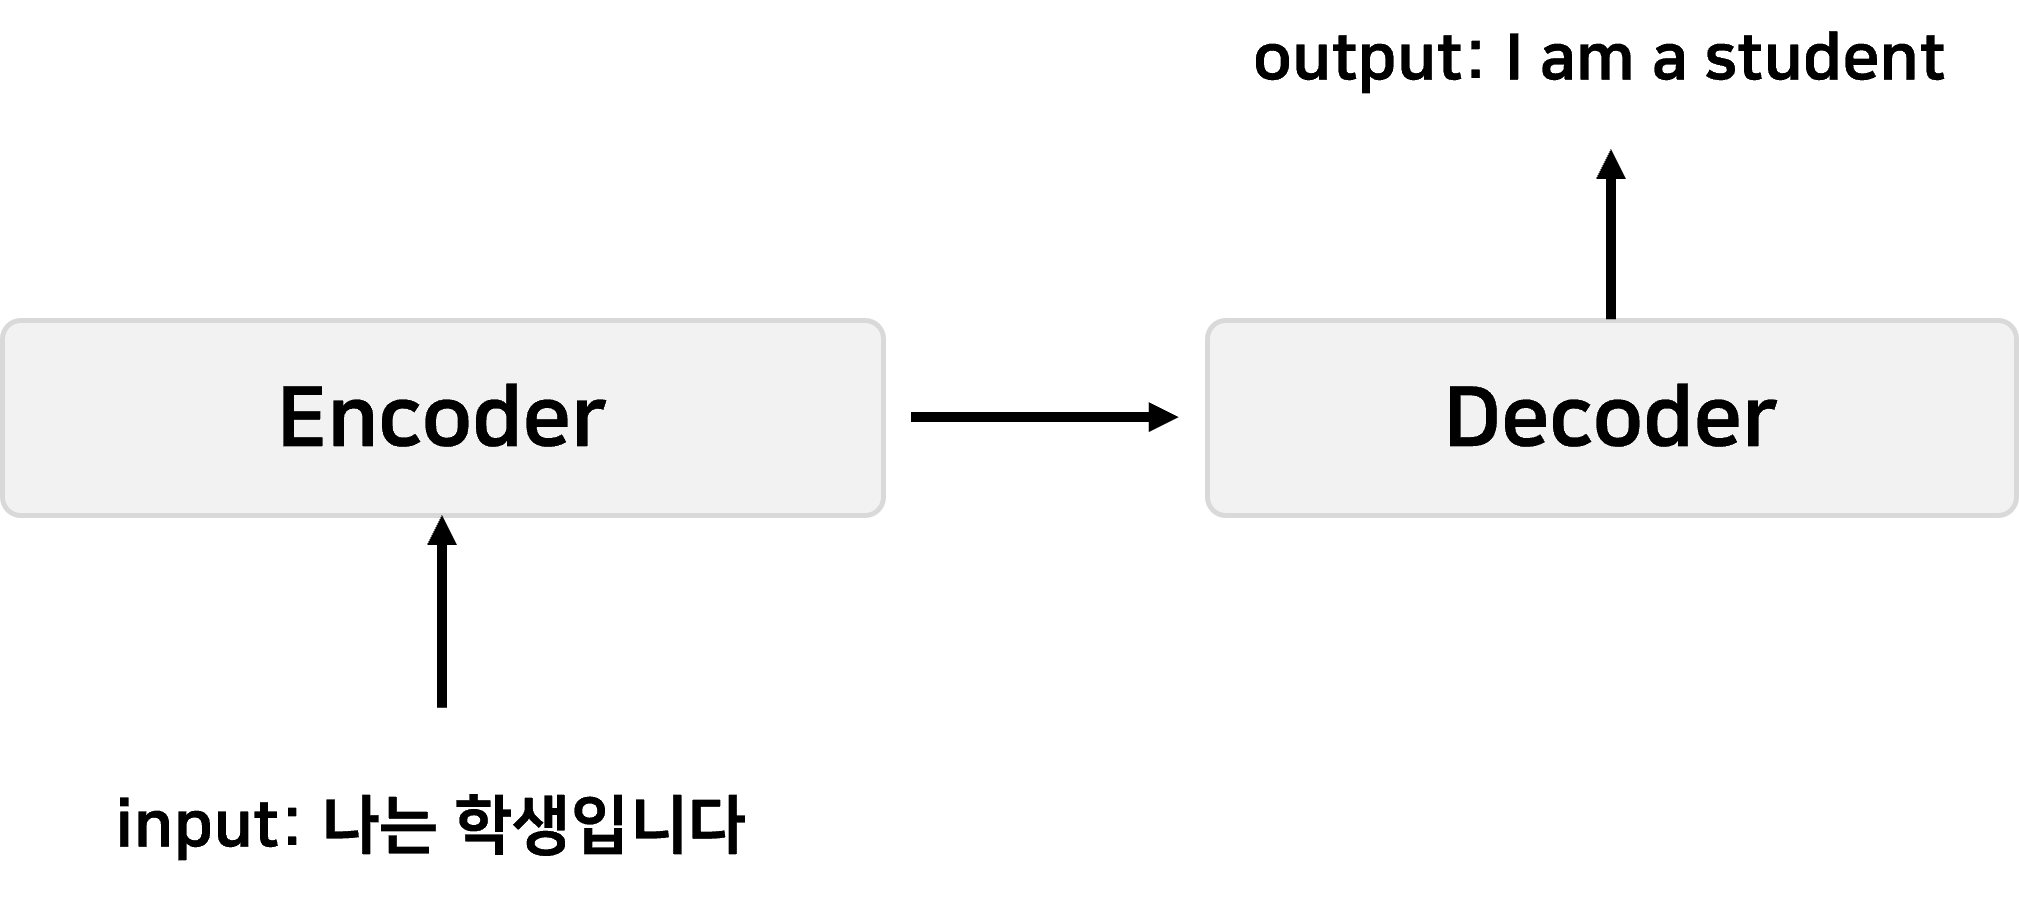

##기초 라이브러리 함수 호출

In [ ]:
import numpy as np
import torch
import torch.nn as nn

###Seq2Seq모델 클래스 초기화

In [ ]:
# 기본적인 사전 단어: 소문자 a~z과 스페셜 토큰으로 사용할 SEP
char_list = [c for c in 'abcdefghijklmnopqrstuvwxyzSEP'] # 문자열을 한 글자씩 쪼갬
num_dic = {n:i for i, n in enumerate(char_list)} # 문자 -> 숫자 인덱스로 매핑하는 딕셔너리
dic_num = {i:n for i, n in enumerate(char_list)} # 반대로 숫자 -> 문자로 매핑. 모델이 예측한 숫자(인덱스)를 다시 사람이 읽을 수 있는 문자로 바꿀 때 씀.

sequence_text = [['man', 'women'], ['black', 'white'], ['king', 'queen'], ['girl', 'boy'], ['up', 'down'], ['high', 'low']] # 학습에 쓸 데이터. 단어 쌍들의 리스트. 각 쌍이 하나의 "샘플"이 되는 구조 (예: seq2seq처럼 입력 단어 → 출력 단어를 매핑하는 용도로 쓰일 가능성 높음. 예를 들어 'man'을 넣으면 'women'을 예측하게 하는 식).

n_class = len(num_dic) # 전체 클래스(문자 종류)개수. 즉 num_dic의 길이 =29
batch_size = len(sequence_text) # 입력 텍스트를 batch 단위로 분할
n_step = 5 # 시퀀스(문자열)의 최대 길이를 5로 고정. RNN/LSTM 계열에서 "몇 개의 타임스텝까지 처리할지"를 정하는 값. 단어 길이가 5보다 짧으면 패딩이 필요해짐.
n_hidden = 128 # RNN/LSTM의 은닉층 크기. 128차원 벡터로 문맥 정보를 압축해서 저장하겠다는 뜻. 숫자가 클수록 표현력은 늘지만 계산량도 늘어남.
d_rate = 0.5 # 드롭아웃(dropout) 비율. 학습 중 뉴런의 50%를 랜덤하게 꺼서 과적합(overfitting)을 방지하는 정규화 기법.

=> char-level(문자 단위) 시퀀스 모델(아마 RNN/LSTM 기반 seq2seq)을 만들기 위한 사전 준비 단계. 문자를 숫자로 바꾸는 사전을 만들고, 학습 데이터(단어 쌍)를 정의하고, 모델의 하이퍼파라미터(배치 크기, 시퀀스 길이, 은닉층 크기, 드롭아웃 비율)를 설정하는 부분

In [ ]:
print("===================================================")
print(sequence_text)
print("===================================================")

[['man', 'women'], ['black', 'white'], ['king', 'queen'], ['girl', 'boy'], ['up', 'down'], ['high', 'low']]


S: start token in decoding input

E: end token in decoding output

P: fill the blank sequence in the sequence text

In [ ]:
def make_batch(): # 학습용 데이터를 담을 빈 리스트 3개 준비
    input_batch, output_batch, target_batch = [], [], [] # input_batch: 인코더에 넣을 입력 (예: 'man') / output_batch: 디코더에 넣을 입력 (예: 'Swomen', 디코더는 SEP의 'S'를 시작 신호로 씀) / target_batch: 디코더가 맞춰야 할 정답 (예: 'womenE', 'E'로 끝을 알림)

    for seq in sequence_text: # sequence_text의 각 쌍(['man', 'women'] 등)을 순회.
        for i in range(2):
            seq[i] += 'P' * (n_step - len(seq[i])) # seq[0](입력 단어)와 seq[1](출력 단어) 둘 다 길이를 n_step(=5)에 맞춰 뒤에 'P'(padding, 채우기용 문자)를 붙여줌.
            # 예: 'man'(길이3) → 'man' + 'P'*(5-3) = 'manPP'(길이5).

        input = [num_dic[i] for i in seq[0]]    # 패딩된 seq[0]('manPP')의 문자를 하나씩 숫자 인덱스로 변환. 결과: [num_dic['m'], num_dic['a'], num_dic['n'], num_dic['P'], num_dic['P']] → 길이 5짜리 정수 리스트.
        output = [num_dic[i] for i in ('S' + seq[1])]    # seq[1](패딩 0개, 'women' 그대로)에 앞에 'S'를 붙임 → 'Swomen'. 디코더 입력은 항상 맨 앞에 시작 토큰 'S'를 붙여서, "여기서부터 출력 시작하라"는 신호를 줌. 문자를 숫자로 변환 → 길이 6짜리 리스트.
        target = [num_dic[i] for i in (seq[1] + 'E')]    # seq[1]('women') 뒤에 'E'(끝 토큰)를 붙여서 'womenE'. 디코더가 예측해야 할 정답값. "언제 출력을 멈춰야 하는지"를 'E'로 학습시키는 것. 마찬가지로 숫자로 변환 → 길이 6짜리 리스트.

        """
        input = ['m', 'a', 'n', 'P', 'P', 'P', 'P', 'P', 'P', 'P']
        output = ['S', 'w', 'o', 'm', 'e', 'n', 'P', 'P', 'P', 'P', 'P']
        target = ['w', 'o', 'm', 'e', 'n', 'P', 'P', 'P', 'P', 'P', 'E']

        """
        # np.eye(n_class)는 n_class × n_class(29×29) 단위행렬을 만듦.
        input_batch.append(np.eye(n_class)[input]) # [input]처럼 정수 리스트로 인덱싱하면, 각 정수에 해당하는 행을 뽑아서 원-핫 인코딩으로 변환해줌.
        output_batch.append(np.eye(n_class)[output])
        target_batch.append(target) # not one-hot : target은 원-핫으로 안 바꾸고 그냥 정수 인덱스 그대로 저장.PyTorch의 CrossEntropyLoss(또는 NLLLoss)는 정답(target)을 원-핫이 아니라 클래스 인덱스(정수)로 받는 걸 기본으로 하기 때문.

    # make tensor
    return torch.FloatTensor(input_batch), torch.FloatTensor(output_batch), torch.LongTensor(target_batch)

이 함수는 Seq2Seq(인코더-디코더) 모델 학습을 위해

각 단어를 고정 길이(n_step)로 패딩하고
디코더 입력엔 시작 토큰 'S', 정답엔 끝 토큰 'E'를 붙이고
문자를 숫자 → (입력/디코더입력은) 원-핫 벡터로, (정답은) 정수 인덱스로 바꿔서
배치 텐서로 묶어 반환하는 전처리 함수야.

In [ ]:
class Seq2Seq(nn.Module): # PyTorch에서 신경망 만들 때 기본 뼈대. nn.Module을 상속받고, 부모 클래스 초기화 해주는 관례적인 코드.
    def __init__(self):
        super(Seq2Seq, self).__init__()

        # 인코더 및 디코더 셀 생성
        self.enc_cell = nn.RNN(input_size=n_class, hidden_size=n_hidden, dropout=d_rate) # 인코더용 RNN. 입력 단어를 읽어서 문맥(의미)을 압축하는 역할.
        self.dec_cell = nn.RNN(input_size=n_class, hidden_size=n_hidden, dropout=d_rate) # 디코더용 RNN. 인코더가 압축한 문맥을 이어받아서, 목표 단어(women 등)를 한 글자씩 생성하는 역할.
        self.fc = nn.Linear(n_hidden, n_class) # 출력층(완전연결층). 디코더의 은닉상태(128차원)를 다시 29차원(문자 종류 개수)으로 변환. 이 29차원 벡터가 각 문자일 확률(정확히는 logit, softmax 전 점수)을 나타냄 → "다음에 어떤 문자가 나올지" 예측하는 부분.

    def forward(self, enc_input, enc_hidden, dec_input):
        # 인코더의 입력 단어, hidden, 디코더의 입력 활용
        enc_input = enc_input.transpose(0, 1)   # enc_input: [max_len(=n_step, time step), batch_size, n_class] => make_batch()에서 만든 텐서는 [batch_size, time_step, n_class] 순서(즉 [6, 5, 29])로 되어 있음. 그래서 transpose(0, 1)로 0번째 축과 1번째 축을 바꿔서 순서를 맞춰줌.
        dec_input = dec_input.transpose(0, 1)   # dec_input: [max_len(=n_step, time step), batch_size, n_class]

        # enc_states : [num_layers(=1) * num_directions(=1), batch_size, n_hidden]
        _, enc_states = self.enc_cell(enc_input, enc_hidden) # 인코더에 입력 시퀀스와 초기 은닉상태(enc_hidden, 보통 0으로 채운 텐서)를 넣음. 반환값은 (outputs, hidden_state) 두 개인데 : 첫 번째(_)는 각 타임스텝마다의 출력값 → 여기선 안 씀(버림, _로 처리). 두 번째(enc_states)는 마지막 타임스텝의 은닉상태 → 이게 바로 "입력 단어 전체를 요약한 문맥 벡터". 이 enc_states가 디코더로 넘어가서 "디코더의 초기 은닉상태"가 됨. 즉 인코더가 이해한 문맥을 디코더에게 넘겨주는 다리 역할.
        # outputs : [max_len+1(=6), batch_size, num_directions(=1) * n_hidden(=128)]
        outputs, _ = self.dec_cell(dec_input, enc_states) # 디코더에 dec_input('Swomen' 등)과, 인코더가 넘겨준 enc_states(초기 은닉상태로 사용)를 넣음.여기선 반대로 각 타임스텝의 출력값(outputs)이 필요하니까 그걸 받고, 마지막 은닉상태(_)는 버림. outputs는 디코더가 매 타임스텝마다 만들어낸 128차원 벡터들의 모음

        model = self.fc(outputs) # model : [max_len+1(=6), batch_size, n_class] -> 디코더의 각 타임스텝 출력(128차원)을 fc 층에 통과시켜서 29차원(문자 종류 개수)으로 변환.

        return model # 최종 예측 결과 반환. 이후 target_batch(정답, [batch, 6]짜리 정수 인덱스)와 비교해서 CrossEntropyLoss로 학습하게 됨.

In [ ]:
# 모델 호출
seq_model = Seq2Seq()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:654: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  super().__init__(mode, *args, **kwargs)


In [ ]:
# 모델 학습 함수

def train():
    criterion = nn.CrossEntropyLoss() # 손실 함수 설정 -> loss 설정
    optimizer = torch.optim.Adam(seq_model.parameters(), lr=0.005) # 옵티마이저, lr=0.005: 학습률(learning rate). 한 번에 가중치를 얼마나 크게 업데이트할지 정하는 값.

    input_batch, output_batch, target_batch = make_batch()

    for epoch in range(5000):
        # make hidden shape [num_layers * num_directions, batch_size, n_hidden] -> num_layers : RNN을 몇 층 쌓았는지 / num_directions : 단방향(1) vs 양방향(2)
        hidden = torch.zeros(1, batch_size, n_hidden) # 인코더의 초기 은닉상태를 0으로 채운 텐서로 만듦.

        optimizer.zero_grad() # 기울기 초기화
        # input_batch : [batch_size, max_len(=n_step, time step), n_class]
        # output_batch : [batch_size, max_len+1(=n_step, time step) (becase of 'S' or 'E'), n_class]
        # target_batch : [batch_size, max_len+1(=n_step, time step)], not one-hot
        output = seq_model(input_batch, hidden, output_batch)
        # output : [max_len+1, batch_size, n_class]
        output = output.transpose(0, 1) # [batch_size, max_len+1(=6), n_class]
        loss = 0
        for i in range(0, len(target_batch)):
            # output[i] : [max_len+1, n_class, target_batch[i] : max_len+1]
            loss += criterion(output[i], target_batch[i])
        if (epoch + 1) % 1000 == 0:
            print('Epoch:', '%04d' % (epoch + 1), 'cost =', '{:.6f}'.format(loss))
        loss.backward() # 역전파(backpropagation). 지금까지 계산한 loss를 기준으로, 모델의 모든 가중치에 대해 "이 가중치를 어느 방향으로 얼마나 바꿔야 loss가 줄어드는지"(=기울기, gradient)를 자동으로 계산함.
        optimizer.step() # 방금 계산된 기울기를 바탕으로 실제로 가중치를 업데이트함 (Adam 알고리즘 방식으로).


In [ ]:
train()

/tmp/ipykernel_1557/2456314829.py:25: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.FloatTensor(input_batch), torch.FloatTensor(output_batch), torch.LongTensor(target_batch)


Epoch: 1000 cost = 0.000515
Epoch: 2000 cost = 0.000147
Epoch: 3000 cost = 0.000063
Epoch: 4000 cost = 0.000032
Epoch: 5000 cost = 0.000017


In [ ]:
# 학습된 모델 추론하는 함수

# 추론 batch 생성

# make test batch
def make_testbatch(input_word):
    input_batch, output_batch = [], []

    input_w = input_word + 'P' * (n_step - len(input_word))
    input = [num_dic[n] for n in input_w]
    output = [num_dic[n] for n in 'S' + 'P' * n_step] # 정답 대신 'S' + 'PPPPP'(시작 토큰 + 의미없는 채움 문자들)를 넣어줌.즉 "일단 시작해봐, 뭐가 나올지는 네가 알아서"라는 뜻으로 더미(dummy) 입력을 준 것.


    input_batch = np.eye(n_class)[input]
    output_batch = np.eye(n_class)[output]

    return torch.FloatTensor(input_batch).unsqueeze(0), torch.FloatTensor(output_batch).unsqueeze(0) # unsqueeze(0)은 0번째 자리에 크기 1짜리 차원을 새로 끼워넣는 함수.


def inference(word):
    input_batch, output_batch = make_testbatch(word)

    # make hidden shape [num_layers * num_directions, batch_size, n_hidden]
    hidden = torch.zeros(1, 1, n_hidden)
    output = seq_model(input_batch, hidden, output_batch)
    # output : [max_len+1(=6), batch_size(=1), n_class]

    predict = output.data.max(2, keepdim=True)[1] # n_class축에서 최댓값을 찾아라.
    decoded = [char_list[i] for i in predict]
    end = decoded.index('E')
    translated = ''.join(decoded[:end])

    return translated.replace('P', '')


In [ ]:
print('=============Inference=============')
print('man ->', inference('man'))
print('mans ->', inference('mans'))
print('king ->', inference('king'))
print('black ->', inference('black'))
print('up ->', inference('up'))
print('father ->', inference('father'))
print('sister ->', inference('sister'))

=============Inference=============
man -> women
mans -> women
king -> queen
black -> white
up -> down
father -> low
sister -> low


| | 학습(train) | 추론(inference) |
|---|---|---|
| 디코더 입력 | 실제 정답 ('Swomen') | 더미 값 ('SPPPPP') |
| 목적 | 정답과 비교해서 loss 계산, 가중치 업데이트 | 모델이 스스로 예측한 결과 확인 |
| batch_size | 6 (전체 단어쌍) | 1 (단어 하나씩) |
| 결과 처리 | loss로 취합 | argmax로 문자 뽑고 'E' 전까지 잘라서 문자열 완성 |

### 다양한 방식으로 sequence_text에 입력을 주어 모델 학습 및 그 결과 확인해보기
